##Assignment 3

In [1]:
!wget https://s3.amazonaws.com/keras-datasets/jena_climate_2009_2016.csv.zip
!unzip jena_climate_2009_2016.csv.zip

--2026-04-05 21:38:05--  https://s3.amazonaws.com/keras-datasets/jena_climate_2009_2016.csv.zip
Resolving s3.amazonaws.com (s3.amazonaws.com)... 52.216.219.224, 52.217.170.24, 16.15.218.117, ...
Connecting to s3.amazonaws.com (s3.amazonaws.com)|52.216.219.224|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 13565642 (13M) [application/zip]
Saving to: ‘jena_climate_2009_2016.csv.zip’

jena_climate_2009_2 100%[===================>]  12.94M  23.1MB/s    in 0.6s    

2026-04-05 21:38:05 (23.1 MB/s) - ‘jena_climate_2009_2016.csv.zip’ saved [13565642/13565642]

Archive:  jena_climate_2009_2016.csv.zip
  inflating: jena_climate_2009_2016.csv  
  inflating: __MACOSX/._jena_climate_2009_2016.csv  


Inspecting/Parsing the data set

In [2]:
import numpy as np
import os
import matplotlib.pyplot as plt

fname = os.path.join("jena_climate_2009_2016.csv")

with open(fname) as f:
    data = f.read()

lines = data.split("\n")
header = lines[0].split(",")
lines = lines[1:]
print(header)
print(len(lines))
temperature = np.zeros((len(lines),))
raw_data = np.zeros((len(lines), len(header) - 1))
for i, line in enumerate(lines):
    values = [float(x) for x in line.split(",")[1:]]
    temperature[i] = values[1]
    raw_data[i, :] = values[:]



['"Date Time"', '"p (mbar)"', '"T (degC)"', '"Tpot (K)"', '"Tdew (degC)"', '"rh (%)"', '"VPmax (mbar)"', '"VPact (mbar)"', '"VPdef (mbar)"', '"sh (g/kg)"', '"H2OC (mmol/mol)"', '"rho (g/m**3)"', '"wv (m/s)"', '"max. wv (m/s)"', '"wd (deg)"']
420451


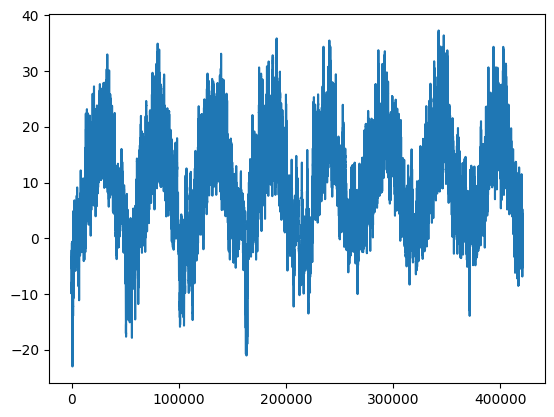

In [3]:
plt.plot(range(len(temperature)), temperature)


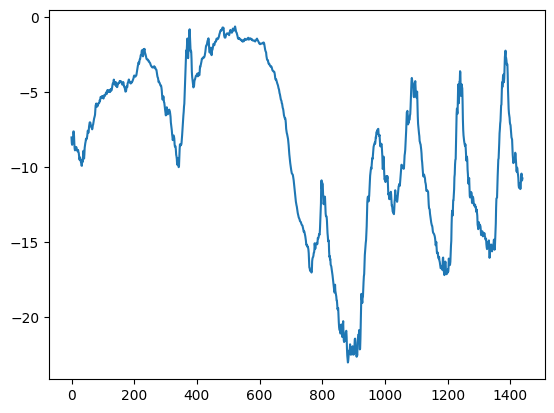

In [4]:
plt.plot(range(1440), temperature[:1440])

In [5]:
num_train_samples = int(0.5 * len(raw_data))
num_val_samples = int(0.25 * len(raw_data))
num_test_samples = len(raw_data) - num_train_samples - num_val_samples
print("num_train_samples:", num_train_samples)
print("num_val_samples:", num_val_samples)
print("num_test_samples:", num_test_samples)

num_train_samples: 210225
num_val_samples: 105112
num_test_samples: 105114


##Preparing the data

In [6]:
import numpy as np
from tensorflow import keras

mean = raw_data[:num_train_samples].mean(axis=0)
raw_data -= mean
std = raw_data[:num_train_samples].std(axis=0)
raw_data /= std

int_sequence = np.arange(10)
dummy_dataset = keras.utils.timeseries_dataset_from_array(
    data=int_sequence[:-3],
    targets=int_sequence[3:],
    sequence_length=3,
    batch_size=2,
)

for inputs, targets in dummy_dataset:
    for i in range(inputs.shape[0]):
        print([int(x) for x in inputs[i]], int(targets[i]))



[0, 1, 2] 3
[1, 2, 3] 4
[2, 3, 4] 5
[3, 4, 5] 6
[4, 5, 6] 7


In [7]:
sampling_rate = 6
sequence_length = 120
delay = sampling_rate * (sequence_length + 24 - 1)
batch_size = 256

train_dataset = keras.utils.timeseries_dataset_from_array(
    raw_data[:-delay],
    targets=temperature[delay:],
    sampling_rate=sampling_rate,
    sequence_length=sequence_length,
    shuffle=True,
    batch_size=batch_size,
    start_index=0,
    end_index=num_train_samples)

val_dataset = keras.utils.timeseries_dataset_from_array(
    raw_data[:-delay],
    targets=temperature[delay:],
    sampling_rate=sampling_rate,
    sequence_length=sequence_length,
    shuffle=True,
    batch_size=batch_size,
    start_index=num_train_samples,
    end_index=num_train_samples + num_val_samples)

test_dataset = keras.utils.timeseries_dataset_from_array(
    raw_data[:-delay],
    targets=temperature[delay:],
    sampling_rate=sampling_rate,
    sequence_length=sequence_length,
    shuffle=True,
    batch_size=batch_size,
    start_index=num_train_samples + num_val_samples)

for samples, targets in train_dataset:
    print("samples shape:", samples.shape)
    print("targets shape:", targets.shape)
    break

samples shape: (256, 120, 14)
targets shape: (256,)


##Common Baseline

In [8]:
def evaluate_naive_method(dataset):
    total_abs_err = 0.
    samples_seen = 0
    for samples, targets in dataset:
        preds = samples[:, -1, 1] * std[1] + mean[1]
        total_abs_err += np.sum(np.abs(preds - targets))
        samples_seen += samples.shape[0]
    return total_abs_err / samples_seen

print(f"Validation MAE: {evaluate_naive_method(val_dataset):.2f}")
print(f"Test MAE: {evaluate_naive_method(test_dataset):.2f}")

Validation MAE: 2.44
Test MAE: 2.62


##Basic Machine Learning Model

Epoch 1/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 42s 50ms/step - loss: 17.1791 - mae: 3.1515 - val_loss: 11.7577 - val_mae: 2.7132
Epoch 2/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 41s 49ms/step - loss: 9.7113 - mae: 2.4569 - val_loss: 10.2250 - val_mae: 2.5316
Epoch 3/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 40s 48ms/step - loss: 8.9364 - mae: 2.3553 - val_loss: 10.6960 - val_mae: 2.5890
Epoch 4/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 40s 49ms/step - loss: 8.4553 - mae: 2.2913 - val_loss: 13.4584 - val_mae: 2.9041
Epoch 5/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 40s 48ms/step - loss: 8.1172 - mae: 2.2446 - val_loss: 10.8950 - val_mae: 2.6235
Epoch 6/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 47s 57ms/step - loss: 7.8238 - mae: 2.2039 - val_loss: 11.6307 - val_mae: 2.6998
Epoch 7/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 40s 48ms/step - loss: 7.6064 - mae: 2.1739 - val_loss: 12.3719 - val_mae: 2.7916
Epoch 8/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 40s 48ms/step - loss: 7.4328 - mae: 2.1474 - val_loss: 10.9123 - val_mae: 2.6228
Epoch 9/10
819/819 ━━━━━━━━━━━━

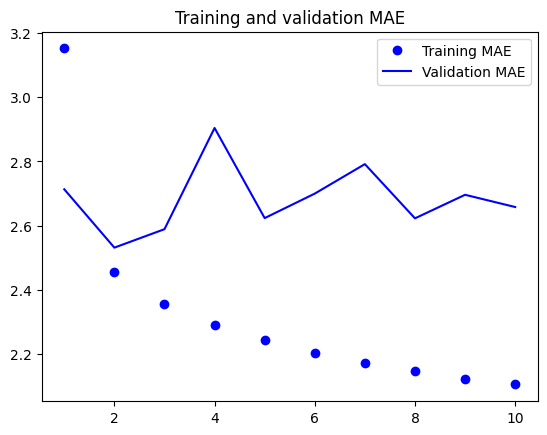

In [9]:
from tensorflow import keras
from tensorflow.keras import layers

inputs = keras.Input(shape=(sequence_length, raw_data.shape[-1]))
x = layers.Flatten()(inputs)
x = layers.Dense(16, activation="relu")(x)
outputs = layers.Dense(1)(x)
model = keras.Model(inputs, outputs)

callbacks = [
    keras.callbacks.ModelCheckpoint("jena_dense.keras",
                                    save_best_only=True)
]
model.compile(optimizer="rmsprop", loss="mse", metrics=["mae"])
history = model.fit(train_dataset,
                    epochs=10,
                    validation_data=val_dataset,
                    callbacks=callbacks)

model = keras.models.load_model("jena_dense.keras")
print(f"Test MAE: {model.evaluate(test_dataset)[1]:.2f}")

loss = history.history["mae"]
val_loss = history.history["val_mae"]
epochs = range(1, len(loss) + 1)
plt.figure()
plt.plot(epochs, loss, "bo", label="Training MAE")
plt.plot(epochs, val_loss, "b", label="Validation MAE")
plt.title("Training and validation MAE")
plt.legend()
plt.show()

##LSTM Model

Epoch 1/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 50s 60ms/step - loss: 40.9508 - mae: 4.7432 - val_loss: 11.9565 - val_mae: 2.6479
Epoch 2/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 48s 58ms/step - loss: 15.2861 - mae: 3.0388 - val_loss: 9.8187 - val_mae: 2.4438
Epoch 3/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 48s 59ms/step - loss: 14.0076 - mae: 2.9188 - val_loss: 9.5641 - val_mae: 2.4213
Epoch 4/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 53s 65ms/step - loss: 13.4698 - mae: 2.8608 - val_loss: 9.5631 - val_mae: 2.4304
Epoch 5/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 48s 59ms/step - loss: 13.1586 - mae: 2.8256 - val_loss: 9.6705 - val_mae: 2.4434
Epoch 6/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 49s 59ms/step - loss: 12.8648 - mae: 2.7944 - val_loss: 9.6367 - val_mae: 2.4360
Epoch 7/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 50s 61ms/step - loss: 12.6718 - mae: 2.7711 - val_loss: 9.4865 - val_mae: 2.4084
Epoch 8/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 82s 60ms/step - loss: 12.3493 - mae: 2.7365 - val_loss: 9.7365 - val_mae: 2.4425
Epoch 9/10
819/819 ━━━━━━━━━━━━

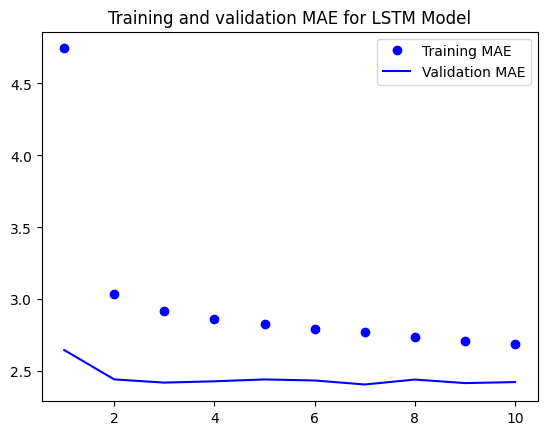

In [31]:
inputs = keras.Input(shape=(sequence_length, raw_data.shape[-1]))
x = layers.LSTM(16,dropout = .2)(inputs)
x = layers.Dropout(0.2)(x)
outputs = layers.Dense(1)(x)
model = keras.Model(inputs, outputs)

callbacks = [
    keras.callbacks.ModelCheckpoint("jena_lstm.keras",
                                    save_best_only=True)
]
model.compile(optimizer="rmsprop", loss="mse", metrics=["mae"])
history = model.fit(train_dataset,
                    epochs=10,
                    validation_data=val_dataset,
                    callbacks=callbacks)

model = keras.models.load_model("jena_lstm.keras")
print(f"Test MAE: {model.evaluate(test_dataset)[1]:.2f}")

loss = history.history["mae"]
val_loss = history.history["val_mae"]
epochs = range(1, len(loss) + 1)
plt.figure()
plt.plot(epochs, loss, "bo", label="Training MAE")
plt.plot(epochs, val_loss, "b", label="Validation MAE")
plt.title("Training and validation MAE for LSTM Model")
plt.legend()
plt.show()

##Stacking RNNs using LSTM

Epoch 1/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 56s 66ms/step - loss: 22.5965 - mae: 3.5083 - val_loss: 9.6879 - val_mae: 2.4167
Epoch 2/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 59s 71ms/step - loss: 11.4097 - mae: 2.6401 - val_loss: 9.1272 - val_mae: 2.3444
Epoch 3/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 52s 63ms/step - loss: 10.3168 - mae: 2.5096 - val_loss: 10.1940 - val_mae: 2.5061
Epoch 4/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 53s 65ms/step - loss: 9.6024 - mae: 2.4180 - val_loss: 9.6249 - val_mae: 2.4304
Epoch 5/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 53s 65ms/step - loss: 8.9734 - mae: 2.3354 - val_loss: 9.8311 - val_mae: 2.4454
Epoch 6/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 55s 67ms/step - loss: 8.4022 - mae: 2.2569 - val_loss: 10.5595 - val_mae: 2.5230
Epoch 7/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 55s 67ms/step - loss: 7.9239 - mae: 2.1885 - val_loss: 10.5782 - val_mae: 2.5246
Epoch 8/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 60s 73ms/step - loss: 7.4540 - mae: 2.1213 - val_loss: 10.3964 - val_mae: 2.5011
Epoch 9/10
819/819 ━━━━━━━━━━━━━━

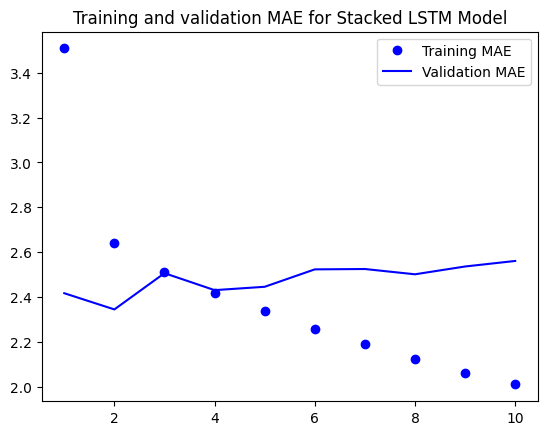

In [32]:
inputs = keras.Input(shape=(sequence_length, raw_data.shape[-1]))
x = layers.LSTM(64, dropout=.2,return_sequences=True)(inputs)
x = layers.LSTM(32, dropout=.2)(x)
x = layers.Dropout(0.2)(x)
outputs = layers.Dense(1)(x)
model = keras.Model(inputs, outputs)

callbacks = [
    keras.callbacks.ModelCheckpoint("jena_stacked_lstm_dropout.keras",
                                    save_best_only=True)
]
model.compile(optimizer="rmsprop", loss="mse", metrics=["mae"])
history = model.fit(train_dataset,
                    epochs=10,
                    validation_data=val_dataset,
                    callbacks=callbacks)
model = keras.models.load_model("jena_stacked_lstm_dropout.keras")
print(f"Test MAE: {model.evaluate(test_dataset)[1]:.2f}")

loss = history.history["mae"]
val_loss = history.history["val_mae"]
epochs = range(1, len(loss) + 1)
plt.figure()
plt.plot(epochs, loss, "bo", label="Training MAE")
plt.plot(epochs, val_loss, "b", label="Validation MAE")
plt.title("Training and validation MAE for Stacked LSTM Model")
plt.legend()
plt.show()

##RNN with 1D Convnent and GRU

Epoch 1/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 49s 59ms/step - loss: 38.0948 - mae: 4.5116 - val_loss: 12.0571 - val_mae: 2.5973
Epoch 2/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 82s 59ms/step - loss: 13.4493 - mae: 2.8423 - val_loss: 9.5108 - val_mae: 2.3855
Epoch 3/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 47s 57ms/step - loss: 12.2328 - mae: 2.7210 - val_loss: 10.3500 - val_mae: 2.5140
Epoch 4/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 47s 57ms/step - loss: 11.6560 - mae: 2.6522 - val_loss: 9.6539 - val_mae: 2.4252
Epoch 5/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 49s 60ms/step - loss: 11.2784 - mae: 2.6073 - val_loss: 9.2408 - val_mae: 2.3639
Epoch 6/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 48s 58ms/step - loss: 10.9995 - mae: 2.5791 - val_loss: 9.4222 - val_mae: 2.3832
Epoch 7/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 48s 58ms/step - loss: 10.7878 - mae: 2.5510 - val_loss: 8.9012 - val_mae: 2.3231
Epoch 8/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 53s 64ms/step - loss: 10.5226 - mae: 2.5225 - val_loss: 9.7672 - val_mae: 2.4365
Epoch 9/10
819/819 ━━━━━━━━━━━

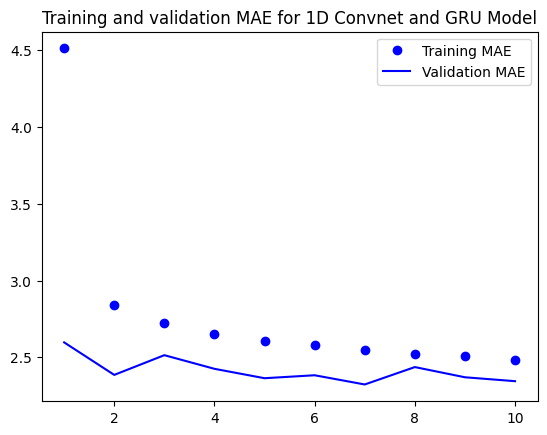

In [35]:
inputs = keras.Input(shape=(sequence_length, raw_data.shape[-1]))
x = layers.Conv1D(32, 5, activation="relu")(inputs)
x = layers.MaxPooling1D(2)(x)
x = layers.GRU(16,dropout=.2)(x)
x = layers.Dropout(0.2)(x)

outputs= layers.Dense(1)(x)
model = keras.Model(inputs, outputs)

callbacks = [
    keras.callbacks.ModelCheckpoint("jena_conv.keras",
                                    save_best_only=True)
]
model.compile(optimizer="rmsprop", loss="mse", metrics=["mae"])
history = model.fit(train_dataset,
                    epochs=10,
                    validation_data=val_dataset,
                    callbacks=callbacks)

model = keras.models.load_model("jena_conv.keras")
print(f"Test MAE: {model.evaluate(test_dataset)[1]:.2f}")


loss = history.history["mae"]
val_loss = history.history["val_mae"]
epochs = range(1, len(loss) + 1)
plt.figure()
plt.plot(epochs, loss, "bo", label="Training MAE")
plt.plot(epochs, val_loss, "b", label="Validation MAE")
plt.title("Training and validation MAE for 1D Convnet and GRU Model")
plt.legend()
plt.show()

##RNN with 1D Convnent and LSTM

Epoch 1/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 50s 59ms/step - loss: 42.0870 - mae: 4.7579 - val_loss: 13.2882 - val_mae: 2.7415
Epoch 2/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 49s 59ms/step - loss: 13.3184 - mae: 2.8248 - val_loss: 10.2584 - val_mae: 2.4734
Epoch 3/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 48s 58ms/step - loss: 12.0090 - mae: 2.6968 - val_loss: 9.5098 - val_mae: 2.3922
Epoch 4/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 49s 59ms/step - loss: 11.4763 - mae: 2.6377 - val_loss: 9.6625 - val_mae: 2.4051
Epoch 5/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 49s 59ms/step - loss: 11.0260 - mae: 2.5850 - val_loss: 9.6633 - val_mae: 2.4125
Epoch 6/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 82s 59ms/step - loss: 10.6933 - mae: 2.5453 - val_loss: 9.7854 - val_mae: 2.4264
Epoch 7/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 49s 59ms/step - loss: 10.4881 - mae: 2.5197 - val_loss: 9.4796 - val_mae: 2.3907
Epoch 8/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 48s 58ms/step - loss: 10.2623 - mae: 2.4916 - val_loss: 9.5718 - val_mae: 2.3983
Epoch 9/10
819/819 ━━━━━━━━━━━

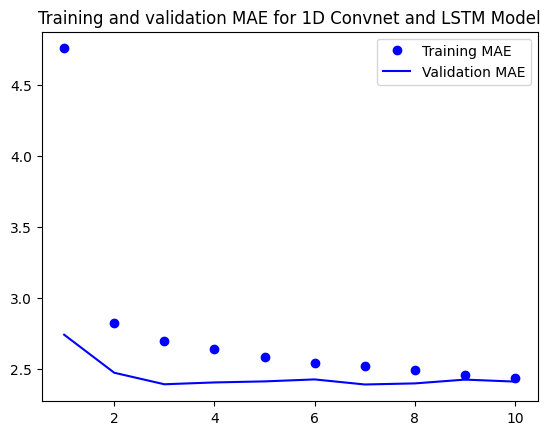

In [37]:
inputs = keras.Input(shape=(sequence_length, raw_data.shape[-1]))
x = layers.Conv1D(32, 5, activation="relu")(inputs)
x = layers.MaxPooling1D(2)(x)
x = layers.LSTM(16,dropout =.2)(x)
x = layers.Dropout(0.2)(x)

outputs = layers.Dense(1)(x)
model = keras.Model(inputs, outputs)

callbacks = [
    keras.callbacks.ModelCheckpoint("jena_conv_lstm.keras",
                                    save_best_only=True)
]
model.compile(optimizer="rmsprop", loss="mse", metrics=["mae"])
history = model.fit(train_dataset,
                    epochs=10,
                    validation_data=val_dataset,
                    callbacks=callbacks)

model = keras.models.load_model("jena_conv_lstm.keras")
print(f"Test MAE: {model.evaluate(test_dataset)[1]:.2f}")


loss = history.history["mae"]
val_loss = history.history["val_mae"]
epochs = range(1, len(loss) + 1)
plt.figure()
plt.plot(epochs, loss, "bo", label="Training MAE")
plt.plot(epochs, val_loss, "b", label="Validation MAE")
plt.title("Training and validation MAE for 1D Convnet and LSTM Model")
plt.legend()
plt.show()